# Perfect Pitch AI
### Intelligent Pitch-Calling System for Catchers

Recommends the optimal **pitch type + PitchCom location** for every pitch in a matchup.

**Architecture:**
- Rule-based strategy engine (count logic, sequencing, tunneling)
- XGBoost ML model trained on 2024–2025 Statcast data
- Pressure / clutch metrics (leverage index, postseason splits)
- Real-time at-bat tracker (updates after every pitch)
- PitchCom-compatible output: `[PITCH TYPE] → [LOCATION]`

**Quick start:**
```python
ai = PerfectPitchAI()
ai.load_matchup('Tyler Glasnow', 'Juan Soto')
ai.start_at_bat(inning=7, outs=1, on_base='_2_', home_score=2, away_score=2, game_type='W')
ai.get_recommendation()
```

In [26]:
# Install dependencies (run once)
import subprocess, sys
for pkg in ['pybaseball', 'xgboost', 'seaborn', 'tqdm']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('Dependencies ready.')


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Dependencies ready.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [27]:
import warnings, os, pickle, time
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pybaseball import statcast_pitcher, statcast_batter, playerid_lookup
import pybaseball
pybaseball.cache.enable()

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import HistGradientBoostingClassifier  # fast, no 32-bit issues

# ── Seasons ───────────────────────────────────────────────────────────────────
SEASONS = {
    '2024': ('2024-03-28', '2024-11-01'),
    '2025': ('2025-03-27', '2025-10-01'),
}

# ── Pitch types ───────────────────────────────────────────────────────────────
PITCH_TYPES = {
    'FF': '4-Seam Fastball',
    'SI': '2-Seam / Sinker',
    'FC': 'Cutter',
    'SL': 'Slider',
    'ST': 'Sweeper',
    'CU': 'Curveball',
    'KC': 'Knuckle Curve',
    'CH': 'Changeup',
    'FS': 'Splitter',
}

# ── PitchCom zone mapping (catcher view) ──────────────────────────────────────
#  Statcast zones:   1|2|3 (top)  4|5|6 (mid)  7|8|9 (bot)
#  Shadow zones:    11,12 (low)   13,14 (sides)
ZONE_TO_PITCHCOM = {
    1:  {'dir': 'Up-In',      'desc': 'Up and in'},
    2:  {'dir': 'Up',         'desc': 'Up in the zone'},
    3:  {'dir': 'Up-Away',    'desc': 'Up and away'},
    4:  {'dir': 'In',         'desc': 'Middle-in'},
    5:  {'dir': 'Middle',     'desc': 'Middle of zone'},
    6:  {'dir': 'Away',       'desc': 'Middle-away'},
    7:  {'dir': 'Down-In',    'desc': 'Down and in'},
    8:  {'dir': 'Down',       'desc': 'Down in zone'},
    9:  {'dir': 'Down-Away',  'desc': 'Down and away'},
    11: {'dir': 'Chase-Down', 'desc': 'Below zone (chase)'},
    12: {'dir': 'Chase-Down', 'desc': 'Below zone (chase)'},
    13: {'dir': 'Chase-In',   'desc': 'Off plate inside (chase)'},
    14: {'dir': 'Chase-Away', 'desc': 'Off plate away (chase)'},
}

# ── Known player IDs ──────────────────────────────────────────────────────────
KNOWN_PLAYERS = {
    'Tyler Glasnow':   607192,
    'Juan Soto':       665742,
    'Shohei Ohtani':   660271,
    'Freddie Freeman': 518692,
    'Gerrit Cole':     543037,
    'Aaron Judge':     592450,
    'Mookie Betts':    605141,
    'Paul Skenes':     694973,
    'Zack Wheeler':    554430,
}

# ── Outcome sets ──────────────────────────────────────────────────────────────
SWING_DESC  = {'swinging_strike','swinging_strike_blocked','foul',
               'foul_tip','hit_into_play','hit_into_play_no_out','hit_into_play_score'}
WHIFF_DESC  = {'swinging_strike','swinging_strike_blocked'}
FAVORABLE_DESC   = {'swinging_strike','swinging_strike_blocked','called_strike','foul_tip'}
FAVORABLE_EVENTS = {'strikeout','field_out','grounded_into_double_play',
                    'force_out','fielders_choice','fielders_choice_out',
                    'sac_fly','sac_bunt','double_play'}
POSTSEASON = {'D','L','W'}

print('Config loaded.')
print(f'  Seasons: {list(SEASONS)}')
print(f'  Pitch types: {len(PITCH_TYPES)}')
print(f'  PitchCom zones: {len(ZONE_TO_PITCHCOM)}')


Config loaded.
  Seasons: ['2024', '2025']
  Pitch types: 9
  PitchCom zones: 13


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# DATA FETCHER
# ─────────────────────────────────────────────────────────────────────────────
class StatcastDataFetcher:
    """Fetches pitcher/batter Statcast data. Caches to disk (24-hour TTL)."""

    def __init__(self, cache_dir='./perfect_pitch_cache'):
        self.cache_dir = cache_dir
        os.makedirs(cache_dir, exist_ok=True)

    def _path(self, key):
        return os.path.join(self.cache_dir, f'{key}.pkl')

    def _load(self, key):
        p = self._path(key)
        if os.path.exists(p) and (time.time() - os.path.getmtime(p)) / 3600 < 24:
            with open(p, 'rb') as f:
                return pickle.load(f)
        return None

    def _save(self, key, data):
        with open(self._path(key), 'wb') as f:
            pickle.dump(data, f)

    def get_pitcher_data(self, player_id: int, name: str) -> pd.DataFrame:
        key = f'pitcher_{player_id}'
        cached = self._load(key)
        if cached is not None:
            print(f'  [Cache] {name}: {len(cached):,} pitches')
            return cached
        frames = []
        for season, (start, end) in SEASONS.items():
            try:
                print(f'  [Fetch] {name} {season}...', end=' ')
                df = statcast_pitcher(start_dt=start, end_dt=end, player_id=player_id)
                if df is not None and len(df) > 0:
                    df['season'] = int(season)
                    frames.append(df)
                    print(f'{len(df):,} pitches')
                else:
                    print('no data')
                time.sleep(1)
            except Exception as e:
                print(f'ERROR: {e}')
        if not frames:
            raise ValueError(f'No pitcher data for {name} (ID={player_id})')
        result = pd.concat(frames, ignore_index=True)
        self._save(key, result)
        return result

    def get_batter_data(self, player_id: int, name: str) -> pd.DataFrame:
        key = f'batter_{player_id}'
        cached = self._load(key)
        if cached is not None:
            print(f'  [Cache] {name}: {len(cached):,} pitches')
            return cached
        frames = []
        for season, (start, end) in SEASONS.items():
            try:
                print(f'  [Fetch] {name} {season}...', end=' ')
                df = statcast_batter(start_dt=start, end_dt=end, player_id=player_id)
                if df is not None and len(df) > 0:
                    df['season'] = int(season)
                    frames.append(df)
                    print(f'{len(df):,} pitches')
                else:
                    print('no data')
                time.sleep(1)
            except Exception as e:
                print(f'ERROR: {e}')
        if not frames:
            raise ValueError(f'No batter data for {name} (ID={player_id})')
        result = pd.concat(frames, ignore_index=True)
        self._save(key, result)
        return result


def lookup_player(name: str) -> Optional[int]:
    """Look up MLB player ID by name."""
    parts = name.strip().split()
    if len(parts) < 2:
        print('Provide full name: First Last')
        return None
    try:
        result = playerid_lookup(parts[-1], parts[0])
        if len(result) == 0:
            print(f'Not found: {name}')
            return None
        cols = [c for c in ['name_first','name_last','key_mlbam','mlb_played_last'] if c in result.columns]
        print(result[cols].to_string(index=False))
        if 'mlb_played_last' in result.columns:
            result = result.sort_values('mlb_played_last', ascending=False)
        pid = int(result.iloc[0]['key_mlbam'])
        print(f'MLB ID: {pid}')
        return pid
    except Exception as e:
        print(f'Lookup failed: {e}')
        return None


print('StatcastDataFetcher ready.')

StatcastDataFetcher ready.


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# LEVERAGE INDEX & PRESSURE METRICS
# ─────────────────────────────────────────────────────────────────────────────
# Leverage Index quantifies how much a PA can swing the game outcome.
# We compute a simplified LI from game state, then layer postseason context.
#
# Pressure tiers:
#   Low      LI < 0.85   (blowout / very early innings)
#   Normal   0.85–1.5    (standard game situation)
#   High     1.5–2.5     (late, close, runners on)
#   Extreme  > 2.5       (postseason, walk-off, elimination)

PRESSURE_TIERS = {
    'Low':     (0.0,  0.85),
    'Normal':  (0.85, 1.5),
    'High':    (1.5,  2.5),
    'Extreme': (2.5,  10.0),
}


def compute_leverage(row) -> float:
    """Return a leverage score [0.1, 5.0] for a Statcast row or dict."""
    score = 1.0
    try:
        diff = abs(int(row.get('home_score', 0)) - int(row.get('away_score', 0)))
    except Exception:
        diff = 0
    if   diff == 0: score *= 1.5
    elif diff == 1: score *= 1.3
    elif diff == 2: score *= 1.1
    elif diff >= 5: score *= 0.35

    try:
        inning = int(row.get('inning', 1))
    except Exception:
        inning = 1
    if   inning >= 9: score *= 2.0
    elif inning >= 7: score *= 1.6
    elif inning >= 5: score *= 1.2
    else:             score *= 0.85

    on_2b = 1 if pd.notna(row.get('on_2b')) else 0
    on_3b = 1 if pd.notna(row.get('on_3b')) else 0
    on_1b = 1 if pd.notna(row.get('on_1b')) else 0
    runners = on_1b + on_2b + on_3b
    if on_2b or on_3b: score *= 1.3
    if runners == 3:   score *= 1.2

    try:
        outs = int(row.get('outs_when_up', 0))
    except Exception:
        outs = 0
    if outs == 2: score *= 1.1

    gt = str(row.get('game_type', 'R'))
    if   gt == 'W': score *= 2.5
    elif gt == 'L': score *= 2.0
    elif gt == 'D': score *= 1.7

    return round(min(score, 5.0), 3)


def add_leverage(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['leverage'] = df.apply(compute_leverage, axis=1)
    return df


def _tier_stats_pitcher(sub: pd.DataFrame) -> Optional[dict]:
    n = len(sub)
    if n == 0:
        return None
    swings = sub[sub['description'].isin(SWING_DESC)]
    whiffs = sub[sub['description'].isin(WHIFF_DESC)]
    in_z   = sub[sub['zone'].between(1, 9)]
    out_z  = sub[sub['zone'].isin([11,12,13,14])]
    chase  = out_z[out_z['description'].isin(SWING_DESC)]
    ks     = sub[sub['events'] == 'strikeout']
    return {
        'n':          n,
        'whiff_rate': len(whiffs) / len(swings) if len(swings) > 0 else 0,
        'zone_rate':  len(in_z)  / n,
        'chase_rate': len(chase) / len(out_z) if len(out_z) > 0 else 0,
        'k_rate':     len(ks)    / n * 100,
    }


def _tier_stats_batter(sub: pd.DataFrame) -> Optional[dict]:
    n = len(sub)
    if n == 0:
        return None
    swings = sub[sub['description'].isin(SWING_DESC)]
    whiffs = sub[sub['description'].isin(WHIFF_DESC)]
    out_z  = sub[sub['zone'].isin([11,12,13,14])]
    chase  = out_z[out_z['description'].isin(SWING_DESC)]
    pas    = sub[sub['events'].notna()]
    ks     = sub[sub['events'] == 'strikeout']
    return {
        'n':          n,
        'swing_rate': len(swings) / n,
        'whiff_rate': len(whiffs) / len(swings) if len(swings) > 0 else 0,
        'chase_rate': len(chase)  / len(out_z)  if len(out_z)  > 0 else 0,
        'k_rate':     len(ks)     / len(pas)     if len(pas)    > 0 else 0,
    }


def pitcher_pressure_profile(df: pd.DataFrame) -> dict:
    """Pitcher effectiveness split by pressure tier + postseason."""
    df = add_leverage(df)
    df = df[df['pitch_type'].isin(PITCH_TYPES)]
    out = {}
    for tier, (lo, hi) in PRESSURE_TIERS.items():
        mask = (df['leverage'] >= lo) & (df['leverage'] < hi)
        s = _tier_stats_pitcher(df[mask])
        if s: out[tier] = s
    for label, mask in [('Postseason', df['game_type'].isin(POSTSEASON)),
                        ('Regular',    df['game_type'] == 'R')]:
        s = _tier_stats_pitcher(df[mask])
        if s: out[label] = s
    if 'High' in out and 'Normal' in out:
        d = out['High']['whiff_rate'] - out['Normal']['whiff_rate']
        if   d >  0.03: interp = 'CLUTCH — Pitcher BETTER under pressure'
        elif d < -0.03: interp = 'SHAKY — Pitcher WORSE under pressure'
        else:           interp = 'CONSISTENT — Stable under pressure'
        out['clutch_delta'] = {'whiff_delta': round(d, 4), 'interpretation': interp}
    return out


def batter_pressure_profile(df: pd.DataFrame) -> dict:
    """Batter vulnerability split by pressure tier + postseason."""
    df = add_leverage(df)
    out = {}
    for tier, (lo, hi) in PRESSURE_TIERS.items():
        mask = (df['leverage'] >= lo) & (df['leverage'] < hi)
        s = _tier_stats_batter(df[mask])
        if s: out[tier] = s
    for label, mask in [('Postseason', df['game_type'].isin(POSTSEASON)),
                        ('Regular',    df['game_type'] == 'R')]:
        s = _tier_stats_batter(df[mask])
        if s: out[label] = s
    if 'High' in out and 'Normal' in out:
        cd = out['High']['chase_rate'] - out['Normal']['chase_rate']
        wd = out['High']['whiff_rate'] - out['Normal']['whiff_rate']
        if   cd > 0.05 or wd > 0.03: interp = 'EXPLOITABLE — Batter chases/misses MORE under pressure'
        elif cd < -0.05 or wd < -0.03: interp = 'CLUTCH — Batter MORE disciplined under pressure'
        else:                          interp = 'CONSISTENT — Batter stable under pressure'
        out['clutch_delta'] = {'chase_delta': round(cd,4), 'whiff_delta': round(wd,4), 'interpretation': interp}
    return out


print('Leverage Index and Pressure Metrics ready.')

Leverage Index and Pressure Metrics ready.


In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# PITCHER PROFILE
# ─────────────────────────────────────────────────────────────────────────────
class PitcherProfile:
    """Comprehensive pitcher profile: repertoire, count/zone/sequence tendencies,
    and pressure splits from 2024-2025 Statcast data."""

    def __init__(self, pitcher_id: int, name: str, data: pd.DataFrame):
        self.pitcher_id = pitcher_id
        self.name       = name
        self.data       = data
        df = data[data['pitch_type'].isin(PITCH_TYPES)].copy()
        self.handedness       = df['p_throws'].mode()[0] if 'p_throws' in df.columns else 'R'
        self.repertoire       = self._repertoire(df)
        self.count_tendencies = self._count_tend(df)
        self.zone_tendencies  = self._zone_tend(df)
        self.sequences        = self._sequences(df)
        self.pressure         = pitcher_pressure_profile(data)

    def _repertoire(self, df):
        rep, total = {}, len(df)
        for pt, g in df.groupby('pitch_type'):
            n      = len(g)
            sw     = g[g['description'].isin(SWING_DESC)]
            wh     = g[g['description'].isin(WHIFF_DESC)]
            iz     = g[g['zone'].between(1,9)]
            oz     = g[g['zone'].isin([11,12,13,14])]
            chase  = oz[oz['description'].isin(SWING_DESC)]
            cstr   = g[g['description'] == 'called_strike']
            rep[pt] = {
                'name':       PITCH_TYPES[pt],
                'usage_pct':  n / total * 100,
                'count':      n,
                'avg_velo':   g['release_speed'].mean(),
                'whiff_rate': len(wh) / len(sw) if len(sw) > 0 else 0,
                'zone_rate':  len(iz) / n,
                'chase_rate': len(chase) / len(oz) if len(oz) > 0 else 0,
                'csw_rate':   (len(cstr) + len(wh)) / n,
            }
        return rep

    def _count_tend(self, df):
        df = df[df['balls'].notna() & df['strikes'].notna()].copy()
        df['cnt'] = df['balls'].astype(int).astype(str) + '-' + df['strikes'].astype(int).astype(str)
        out = {}
        for cnt, g in df.groupby('cnt'):
            if len(g) < 5: continue
            out[cnt] = {'n': len(g), 'dist': g['pitch_type'].value_counts(normalize=True).to_dict(),
                        'top': g['pitch_type'].mode()[0]}
        return out

    def _zone_tend(self, df):
        out = {}
        for pt, g in df.groupby('pitch_type'):
            out[pt] = {'zone_dist': g['zone'].value_counts(normalize=True).to_dict()}
        return out

    def _sequences(self, df):
        """Markov transition P(next_pitch | prev_pitch) within same AB."""
        trans = defaultdict(lambda: defaultdict(int))
        df_s  = df.sort_values(['game_pk','at_bat_number','pitch_number'])
        prev_pt = prev_gm = prev_ab = None
        for _, row in df_s.iterrows():
            gm, ab, pt = row['game_pk'], row['at_bat_number'], row['pitch_type']
            if prev_pt and gm == prev_gm and ab == prev_ab:
                trans[prev_pt][pt] += 1
            prev_pt, prev_gm, prev_ab = pt, gm, ab
        probs = {}
        for prev, nexts in trans.items():
            total = sum(nexts.values())
            probs[prev] = {nxt: cnt/total for nxt,cnt in nexts.items()}
        return probs

    def summarize(self):
        print(f'\n{"="*60}')
        print(f'  PITCHER: {self.name}  ({self.handedness}HP)')
        print(f'{"="*60}')
        print(f'  {"Pitch":<22} {"Use%":>5}  {"Velo":>8}  {"Whiff%":>7}  {"CSW%":>6}')
        print(f'  {"-"*55}')
        for pt, s in sorted(self.repertoire.items(), key=lambda x: -x[1]['usage_pct']):
            v = f"{s['avg_velo']:.1f}" if pd.notna(s['avg_velo']) else '  N/A'
            print(f"  {s['name']:<22} {s['usage_pct']:>5.1f}%  {v:>7} mph  "
                  f"{s['whiff_rate']*100:>6.1f}%  {s['csw_rate']*100:>5.1f}%")
        print('\n  Pressure splits (Whiff% | Zone% | n):')
        for tier in ['Low','Normal','High','Extreme']:
            if tier in self.pressure:
                p = self.pressure[tier]
                print(f"    {tier:<8}  {p['whiff_rate']*100:.1f}%  |  "
                      f"{p['zone_rate']*100:.1f}%  |  n={p['n']:,}")
        if 'clutch_delta' in self.pressure:
            print(f"\n  >>> {self.pressure['clutch_delta']['interpretation']}")
        if 'Postseason' in self.pressure:
            ps = self.pressure['Postseason']
            print(f"\n  Postseason: {ps['n']} pitches | Whiff {ps['whiff_rate']*100:.1f}%")


print('PitcherProfile ready.')

PitcherProfile ready.


In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# BATTER PROFILE
# ─────────────────────────────────────────────────────────────────────────────
class BatterProfile:
    """Batter vulnerability profile: zone heat map, pitch-type weaknesses,
    count aggressiveness, and pressure splits."""

    def __init__(self, batter_id: int, name: str, data: pd.DataFrame):
        self.batter_id = batter_id
        self.name      = name
        self.data      = data
        df = data[data['pitch_type'].notna()].copy()
        self.stands     = df['stand'].mode()[0] if 'stand' in df.columns else 'R'
        self.zone_map   = self._zone_map(df)
        self.pt_map     = self._pt_map(df)
        self.count_map  = self._count_map(df)
        self.discipline = self._discipline(df)
        self.pressure   = batter_pressure_profile(data)

    def _zone_map(self, df):
        out = {}
        for zone in list(range(1,10)) + [11,12,13,14]:
            g = df[df['zone'] == zone]
            if len(g) < 3: continue
            n  = len(g)
            sw = g[g['description'].isin(SWING_DESC)]
            wh = g[g['description'].isin(WHIFF_DESC)]
            hi = g[g['description'].str.contains('hit_into_play', na=False)]
            hh = hi[hi['launch_speed'] >= 95] if 'launch_speed' in hi.columns else pd.DataFrame()
            out[int(zone)] = {
                'n':          n,
                'swing_rate': len(sw) / n,
                'whiff_rate': len(wh) / len(sw) if len(sw) > 0 else 0,
                'hard_hit':   len(hh) / len(hi) if len(hi) > 0 else 0,
                'pitchcom':   ZONE_TO_PITCHCOM.get(zone, {}).get('dir', 'Middle'),
            }
        return out

    def _pt_map(self, df):
        out = {}
        for pt, g in df.groupby('pitch_type'):
            if pt not in PITCH_TYPES or len(g) < 5: continue
            n  = len(g)
            sw = g[g['description'].isin(SWING_DESC)]
            wh = g[g['description'].isin(WHIFF_DESC)]
            oz = g[g['zone'].isin([11,12,13,14])]
            ch = oz[oz['description'].isin(SWING_DESC)]
            out[pt] = {
                'name':       PITCH_TYPES[pt],
                'n':          n,
                'swing_rate': len(sw) / n,
                'whiff_rate': len(wh) / len(sw) if len(sw) > 0 else 0,
                'chase_rate': len(ch) / len(oz) if len(oz) > 0 else 0,
            }
        return out

    def _count_map(self, df):
        df = df[df['balls'].notna() & df['strikes'].notna()].copy()
        df['cnt'] = df['balls'].astype(int).astype(str) + '-' + df['strikes'].astype(int).astype(str)
        out = {}
        for cnt, g in df.groupby('cnt'):
            if len(g) < 3: continue
            sw = g[g['description'].isin(SWING_DESC)]
            sr = len(sw) / len(g)
            out[cnt] = {'n': len(g), 'swing_rate': sr, 'aggressive': sr > 0.55}
        return out

    def _discipline(self, df):
        iz = df[df['zone'].between(1,9)]
        oz = df[df['zone'].isin([11,12,13,14])]
        zs = iz[iz['description'].isin(SWING_DESC)]
        cs = oz[oz['description'].isin(SWING_DESC)]
        al = df[df['description'].isin(SWING_DESC)]
        return {
            'z_swing':     len(zs) / len(iz) if len(iz) > 0 else 0,
            'chase_rate':  len(cs) / len(oz) if len(oz) > 0 else 0,
            'swing_rate':  len(al) / len(df) if len(df) > 0 else 0,
        }

    def vulnerabilities(self) -> List[dict]:
        """Rank all (pitch_type, zone) pairs by exploitation score."""
        vulns = []
        for zone, zs in self.zone_map.items():
            for pt, ps in self.pt_map.items():
                score = zs['whiff_rate']*0.4 + ps['whiff_rate']*0.4 + ps['chase_rate']*0.2
                vulns.append({
                    'pitch_type': pt, 'zone': zone,
                    'pitchcom': zs['pitchcom'],
                    'score': score,
                    'zone_whiff': zs['whiff_rate'],
                    'pt_whiff': ps['whiff_rate'],
                    'pt_chase': ps['chase_rate'],
                    'hard_hit_risk': zs.get('hard_hit', 0),
                })
        return sorted(vulns, key=lambda x: -x['score'])

    def summarize(self):
        print(f'\n{"="*60}')
        print(f'  BATTER: {self.name}  ({self.stands}HB)')
        print(f'{"="*60}')
        d = self.discipline
        print(f"  Discipline — Z-Swing: {d['z_swing']*100:.1f}%  "
              f"Chase: {d['chase_rate']*100:.1f}%  Overall: {d['swing_rate']*100:.1f}%")
        print(f'\n  vs Pitch types  {"Swing%":>7}  {"Whiff%":>7}  {"Chase%":>7}')
        print(f'  {"-"*48}')
        for pt, s in sorted(self.pt_map.items(), key=lambda x: -x[1]['whiff_rate']):
            print(f"  {s['name']:<22} {s['swing_rate']*100:>6.1f}%  "
                  f"{s['whiff_rate']*100:>6.1f}%  {s['chase_rate']*100:>6.1f}%")
        print('\n  Pressure splits (Chase% | Whiff% | n):')
        for tier in ['Low','Normal','High','Extreme']:
            if tier in self.pressure:
                p = self.pressure[tier]
                print(f"    {tier:<8}  Chase {p['chase_rate']*100:.1f}%  |  "
                      f"Whiff {p['whiff_rate']*100:.1f}%  |  n={p['n']:,}")
        if 'clutch_delta' in self.pressure:
            print(f"\n  >>> {self.pressure['clutch_delta']['interpretation']}")
        if 'Postseason' in self.pressure:
            ps = self.pressure['Postseason']
            print(f"\n  Postseason: {ps['n']} pitches | Chase {ps['chase_rate']*100:.1f}%")


print('BatterProfile ready.')

BatterProfile ready.


In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# RULE-BASED ENGINE
# ─────────────────────────────────────────────────────────────────────────────
class RuleEngine:
    """Score every (pitch_type, zone) candidate using baseball strategy rules.

    Rules cover: count state, pitch sequencing, tunneling, zone targeting,
    batter vulnerability, and pressure-adjusted priority.
    """

    PITCHER_COUNTS = {'0-1','0-2','1-2','2-2'}
    HITTER_COUNTS  = {'1-0','2-0','3-0','3-1'}

    # Classic setup → out pitch combos
    SETUPS = {
        'FF': ['SL','ST','CH','CU'],
        'SI': ['SL','CH','ST'],
        'FC': ['CH','FF','CU'],
        'SL': ['FF','CH'],
        'ST': ['FF','CU'],
        'CU': ['FF','FC'],
        'CH': ['FF','SL'],
    }

    def __init__(self, pitcher: PitcherProfile, batter: BatterProfile):
        self.pitcher = pitcher
        self.batter  = batter
        self._vulns  = {(v['pitch_type'], v['zone']): v
                        for v in batter.vulnerabilities()[:30]}

    def recommend(self, count: str, prev_pitches: List[dict],
                  leverage: float = 1.0) -> List[dict]:
        """Return top-10 ranked recommendations for the current pitch."""
        recs  = []
        last  = prev_pitches[-1] if prev_pitches else None

        for pt, ps in self.pitcher.repertoire.items():
            if ps['usage_pct'] < 2.0:
                continue
            zdist = self.pitcher.zone_tendencies.get(pt, {}).get('zone_dist', {})
            for zone in list(range(1,10)) + [11,12,13,14]:
                freq = zdist.get(float(zone), zdist.get(zone, 0))
                if freq < 0.02:
                    continue
                sc, reasons = self._score(pt, zone, count, last, prev_pitches, ps)
                recs.append({
                    'pitch_type':   pt,
                    'pitch_name':   PITCH_TYPES.get(pt, pt),
                    'zone':         zone,
                    'pitchcom_dir': ZONE_TO_PITCHCOM.get(zone,{}).get('dir','Middle'),
                    'pitchcom_seq': f"[{PITCH_TYPES.get(pt,'').upper()}] → [{ZONE_TO_PITCHCOM.get(zone,{}).get('dir','').upper()}]",
                    'pitchcom_desc':ZONE_TO_PITCHCOM.get(zone,{}).get('desc',''),
                    'score':        sc,
                    'reasons':      reasons,
                    'csw':          ps['csw_rate'],
                    'whiff':        ps['whiff_rate'],
                })

        recs.sort(key=lambda x: -x['score'])
        return self._pressure_adjust(recs, leverage)[:10]

    def _score(self, pt, zone, count, last, prev_pitches, ps):
        sc, reasons = 0.0, []
        sc += ps['whiff_rate'] * 30
        sc += ps['csw_rate']   * 20
        bz = self.batter.zone_map.get(zone, {})
        bp = self.batter.pt_map.get(pt, {})
        if bz:
            sc += bz.get('whiff_rate',0) * 25
            sc -= bz.get('hard_hit',0)   * 20
        if bp:
            sc += bp.get('whiff_rate',0) * 20
            if zone in [11,12,13,14]:
                sc += bp.get('chase_rate',0) * 15
        s, r = self._count_rules(pt, zone, count, ps)
        sc += s; reasons.extend(r)
        if last:
            s, r = self._seq_rules(pt, zone, last, prev_pitches)
            sc += s; reasons.extend(r)
        s, r = self._zone_rules(pt, zone, bz, bp)
        sc += s; reasons.extend(r)
        return sc, reasons

    def _count_rules(self, pt, zone, count, ps):
        sc, r = 0.0, []
        if count in self.PITCHER_COUNTS:
            if zone in [11,12,13,14]:
                sc += 15; r.append(f"Pitcher's count ({count}): expand zone, chase pitch")
            if ps['whiff_rate'] > 0.28:
                sc += 10; r.append(f"Best swing-miss pitch ({ps['whiff_rate']*100:.0f}% whiff) in pitcher's count")
            if count == '0-2' and zone in [11,12,13,14]:
                sc += 20; r.append('0-2: waste/chase strongly preferred')
            if count == '0-2' and zone == 5:
                sc -= 15; r.append('0-2: never gift middle of zone')
        elif count in self.HITTER_COUNTS:
            if 1 <= zone <= 9:
                sc += 20; r.append(f"Hitter's count ({count}): MUST throw strike")
            if pt in ('FF','SI','FC'):
                sc += 10; r.append("Hitter's count: best fastball for strike")
            if zone in [11,12,13,14]:
                sc -= 15; r.append(f"Hitter's count ({count}): avoid walk")
        elif count == '0-0':
            if pt == 'FF' and zone in [1,2,3,4,6]:
                sc += 12; r.append('First pitch: establish fastball, get ahead')
            elif pt in ('SL','CU','ST','CH') and 1 <= zone <= 9:
                sc += 8; r.append('First pitch: early off-speed strike — surprise')
        elif count == '3-2':
            if 1 <= zone <= 9:
                sc += 15; r.append('Full count: need a strike')
            if ps['whiff_rate'] > 0.25:
                sc += 12; r.append('Full count: best strikeout pitch')
        return sc, r

    def _seq_rules(self, pt, zone, last, prev_pitches):
        sc, r = 0.0, []
        lt, lr, lz = last.get('type'), last.get('result',''), last.get('zone',5)
        if lt in self.SETUPS and pt in self.SETUPS[lt]:
            sc += 15; r.append(f'Classic sequence: {lt} → {pt}')
        if pt == lt and zone == lz:
            if lr in ('swinging_strike','called_strike','foul_tip'):
                sc += 8; r.append(f'Repeat {pt} — batter missed it, go back')
            elif lr in ('ball','hit_into_play'):
                sc -= 15; r.append(f'Avoid repeating {pt} to same zone (last: {lr})')
        if lz in [1,4,7] and zone in [3,6,9]:   sc += 8;  r.append('Tunnel: inside → away')
        if lz in [3,6,9] and zone in [1,4,7]:   sc += 8;  r.append('Tunnel: away → inside')
        if lz in [1,2,3] and zone in [7,8,9,11,12]: sc += 10; r.append('Eye level: high → low')
        if lz in [7,8,9] and zone in [1,2,3]:   sc += 10; r.append('Eye level: low → high')
        if lr in ('swinging_strike','swinging_strike_blocked') and lz == zone:
            sc += 12; r.append('Batter whiffed here — exploit again')
        if lr == 'ball' and pt == lt:
            sc -= 8; r.append('Batter laid off same pitch — change type')
        ct = sum(1 for p in prev_pitches if p.get('type') == pt)
        if ct >= 2:
            sc -= 10; r.append(f'{pt} thrown {ct}x this AB — batter may be timing it')
        seq = self.pitcher.sequences.get(lt, {})
        if seq.get(pt, 0) > 0.35:
            sc -= 5; r.append(f'Common {lt}→{pt} for {self.pitcher.name} — batter may expect it')
        elif seq.get(pt, 0) < 0.10 and lt is not None:
            sc += 5; r.append('Unexpected sequence — element of surprise')
        return sc, r

    def _zone_rules(self, pt, zone, bz, bp):
        sc, r = 0.0, []
        if zone in [6,9]:                    sc += 5;  r.append('Down-away: minimal hard-contact zone')
        if zone in [1,4] and pt in ('FF','FC','SI'): sc += 8; r.append('Up-in FB: hard to extend, weak contact')
        if pt in ('SL','CU','KC','ST') and zone in [7,8,9,11,12]: sc += 7; r.append('Low breaking ball: GB / chase')
        if pt == 'CH' and zone in [6,9,14]:  sc += 10; r.append('Changeup low-away: classic out pitch')
        if bz.get('whiff_rate',0) > 0.28:
            sc += 15; r.append(f"Zone {zone} is batter's weak spot ({bz['whiff_rate']*100:.0f}% whiff)")
        if bz.get('hard_hit',0) > 0.25:
            sc -= 12; r.append(f"Zone {zone} is batter's power zone — avoid")
        return sc, r

    def _pressure_adjust(self, recs, lev):
        if lev < 1.0:
            return recs
        cd = self.batter.pressure.get('clutch_delta', {}).get('chase_delta', 0)
        for rec in recs:
            if lev >= 2.0 and rec['whiff'] > 0.28:
                rec['score'] *= 1.15
                rec['reasons'].append(f'HIGH LEVERAGE ({lev:.1f}): prioritise swing-miss pitch')
            if lev >= 1.5 and cd > 0.05 and rec['zone'] in [11,12,13,14]:
                rec['score'] += 12
                rec['reasons'].append(f'PRESSURE: batter chases {cd*100:.0f}% more — use it')
            elif lev >= 1.5 and cd < -0.05 and rec['zone'] in [11,12,13,14]:
                rec['score'] -= 8
                rec['reasons'].append('PRESSURE: batter is disciplined — avoid waste')
            if lev > 2.5 and rec['zone'] in [11,12,13,14]:
                rec['score'] *= 0.85
                rec['reasons'].append('Extreme pressure: reduce chase (no walks)')
        recs.sort(key=lambda x: -x['score'])
        return recs


print('RuleEngine ready.')

RuleEngine ready.


In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# ML MODEL — HistGradientBoostingClassifier
# Predicts P(favorable_outcome | pitch_type, zone, game_state)
# ─────────────────────────────────────────────────────────────────────────────
class PitchOutcomeModel:

    def __init__(self):
        self.model      = None
        self.feat_cols  = []
        self.is_trained = False

    @staticmethod
    def _col(df: pd.DataFrame, col: str, default=0) -> pd.Series:
        """Return df[col] if it exists, else a Series of `default` values."""
        if col in df.columns:
            return df[col]
        return pd.Series([default] * len(df), index=df.index)

    def _featurize(self, df: pd.DataFrame) -> pd.DataFrame:
        c = self._col   # shorthand
        d = pd.DataFrame(index=df.index)

        d['balls']          = pd.to_numeric(c(df,'balls',0),          errors='coerce').fillna(0)
        d['strikes']        = pd.to_numeric(c(df,'strikes',0),        errors='coerce').fillna(0)
        d['count_state']    = d['balls'] * 4 + d['strikes']
        d['pitchers_count'] = (d['strikes'] >= 2).astype(int)
        d['hitters_count']  = ((d['balls'] >= 2) & (d['strikes'] <= 1)).astype(int)
        d['outs']           = pd.to_numeric(c(df,'outs_when_up',0),   errors='coerce').fillna(0)
        d['inning']         = pd.to_numeric(c(df,'inning',1),         errors='coerce').fillna(1)
        d['late_inning']    = (d['inning'] >= 7).astype(int)
        d['on_1b']          = c(df,'on_1b', None).notna().astype(int)
        d['on_2b']          = c(df,'on_2b', None).notna().astype(int)
        d['on_3b']          = c(df,'on_3b', None).notna().astype(int)
        d['runners']        = d['on_1b'] + d['on_2b'] + d['on_3b']
        d['scoring_pos']    = ((d['on_2b'] + d['on_3b']) > 0).astype(int)
        hs                  = pd.to_numeric(c(df,'home_score',0),     errors='coerce').fillna(0)
        as_                 = pd.to_numeric(c(df,'away_score',0),     errors='coerce').fillna(0)
        d['score_diff']     = hs - as_
        d['close_game']     = (d['score_diff'].abs() <= 2).astype(int)
        d['release_speed']  = pd.to_numeric(c(df,'release_speed',92), errors='coerce').fillna(92)
        d['pfx_x']          = pd.to_numeric(c(df,'pfx_x',0),          errors='coerce').fillna(0)
        d['pfx_z']          = pd.to_numeric(c(df,'pfx_z',0),          errors='coerce').fillna(0)
        pt_col              = c(df,'pitch_type','')
        for pt in ['FF','SI','FC','SL','ST','CU','CH']:
            d[f'is_{pt}']   = (pt_col == pt).astype(int)
        d['zone']           = pd.to_numeric(c(df,'zone',5),           errors='coerce').fillna(5)
        d['in_zone']        = d['zone'].between(1, 9).astype(int)
        d['zone_row']       = d['zone'].apply(lambda z: 0 if z in [1,2,3] else 1 if z in [4,5,6] else 2)
        d['zone_col']       = d['zone'].apply(lambda z: int(z) % 3)
        d['chase_zone']     = d['zone'].isin([11,12,13,14]).astype(int)
        d['leverage']       = df.apply(compute_leverage, axis=1)
        d['postseason']     = c(df,'game_type','R').isin(POSTSEASON).astype(int)
        return d.fillna(0)

    def _target(self, df: pd.DataFrame) -> pd.Series:
        return (
            df['description'].isin(FAVORABLE_DESC) |
            df['events'].isin(FAVORABLE_EVENTS)
        ).astype(int)

    def train(self, pitcher_data: pd.DataFrame):
        df = pitcher_data[pitcher_data['pitch_type'].notna()].copy()
        print(f'  Building features for {len(df):,} pitches...')
        X = self._featurize(df)
        y = self._target(df)
        valid = y.notna()
        X, y  = X[valid], y[valid]
        print(f'  Favorable outcome rate: {y.mean()*100:.1f}%')
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y)
        self.model = HistGradientBoostingClassifier(
            max_iter=300, max_depth=6, learning_rate=0.05,
            min_samples_leaf=20, random_state=42)
        self.model.fit(X_tr, y_tr)
        acc = accuracy_score(y_te, self.model.predict(X_te))
        print(f'  Test accuracy: {acc:.3f}')
        self.feat_cols  = list(X.columns)
        self.is_trained = True
        return self

    def score_candidates(self, candidates: List[dict], ctx: dict) -> List[dict]:
        if not self.is_trained:
            return candidates
        rows  = [{**ctx, 'pitch_type': c['pitch_type'], 'zone': c['zone']}
                 for c in candidates]
        X     = self._featurize(pd.DataFrame(rows))[self.feat_cols].fillna(0)
        probs = self.model.predict_proba(X)[:, 1]
        for c, p in zip(candidates, probs):
            c['ml_prob'] = float(p)
        return candidates


print('PitchOutcomeModel (HistGradientBoosting) ready.')


PitchOutcomeModel (HistGradientBoosting) ready.


In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# REAL-TIME AT-BAT TRACKER
# ─────────────────────────────────────────────────────────────────────────────
@dataclass
class PitchRecord:
    num:       int
    pt:        str
    name:      str
    zone:      int
    loc:       str
    result:    str
    events:    str   = ''
    velocity:  float = 0.0


class AtBatTracker:
    """Maintains count, pitch history, momentum, and real-time batter patterns."""

    def __init__(self, pitcher: str, batter: str, game_state: dict):
        self.pitcher    = pitcher
        self.batter     = batter
        self.gs         = game_state
        self.balls      = 0
        self.strikes    = 0
        self.history: List[PitchRecord] = []
        self.complete   = False
        self.result     = None
        self.momentum   = 1.0
        self._pt_results = defaultdict(list)

    @property
    def count(self): return f'{self.balls}-{self.strikes}'

    @property
    def pitch_num(self): return len(self.history) + 1

    @property
    def leverage(self):
        return compute_leverage({**self.gs, 'outs_when_up': self.gs.get('outs',0)})

    def record(self, pr: PitchRecord):
        self.history.append(pr)
        self._pt_results[pr.pt].append(pr.result)
        r = pr.result
        if r in ('swinging_strike','swinging_strike_blocked','called_strike'):
            if self.strikes < 2: self.strikes += 1
            else:
                if pr.events == 'strikeout' or r not in ('foul',):
                    self.complete = True; self.result = 'strikeout'; return
        elif r == 'foul':
            if self.strikes < 2: self.strikes += 1
        elif r == 'ball':
            self.balls += 1
            if self.balls == 4: self.complete = True; self.result = 'walk'; return
        elif r == 'hit_into_play':
            self.complete = True; self.result = pr.events or 'in_play'; return
        if pr.events == 'strikeout':
            self.complete = True; self.result = 'strikeout'; return
        if r in ('swinging_strike','called_strike'): self.momentum = min(self.momentum*1.12, 1.6)
        elif r in ('ball','hit_into_play'):          self.momentum = max(self.momentum*0.88, 0.6)

    def rt_adjustments(self) -> dict:
        """Detect in-AB patterns: is batter struggling or laying off a pitch?"""
        adj = {}
        for pt, results in self._pt_results.items():
            if len(results) < 2: continue
            wh = sum(1 for r in results if 'swinging_strike' in r)
            tk = sum(1 for r in results if r in ('ball','called_strike'))
            if wh/len(results) >= 0.5:
                adj[pt] = {'boost': +12, 'note': f'[REAL-TIME] Batter whiffing on {pt} this AB ({wh}/{len(results)}) — keep going back'}
            elif tk/len(results) >= 0.6:
                adj[pt] = {'boost': -6,  'note': f'[REAL-TIME] Batter laying off {pt} this AB — adjust'}
        return adj

    def prev_dict(self) -> List[dict]:
        return [{'type': p.pt, 'zone': p.zone, 'result': p.result} for p in self.history]

    def show(self):
        lev = self.leverage
        tier = 'Extreme' if lev>2.5 else 'High' if lev>1.5 else 'Normal' if lev>0.85 else 'Low'
        mom  = '🔥 Hot' if self.momentum>1.1 else '❄️  Cold' if self.momentum<0.9 else '— Neutral'
        print(f'\n  Count: {self.count}  |  Leverage: {lev:.2f} [{tier}]  |  Momentum: {mom}')
        if self.history:
            print('  Pitches this AB:')
            rmap = {'swinging_strike':'⚡ WHIFF','called_strike':'✓ K','ball':'○ Ball',
                    'foul':'~ Foul','hit_into_play':'→ In Play'}
            for p in self.history:
                print(f'    #{p.num}  {p.name:<22} [{p.loc}]  {rmap.get(p.result, p.result)}')


print('AtBatTracker ready.')

AtBatTracker ready.


In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# PITCHCOM DISPLAY
# ─────────────────────────────────────────────────────────────────────────────
def _result_str(r):
    return {'swinging_strike':'⚡ SWINGING STRIKE','swinging_strike_blocked':'⚡ SWINGING STRIKE',
            'called_strike':'✓  CALLED STRIKE','ball':'○  BALL',
            'foul':'~  FOUL','foul_tip':'~  FOUL TIP',
            'hit_into_play':'→  IN PLAY'}.get(r, r.upper())


def display_card(rec: dict, rank: int, count: str, leverage: float):
    llab = ('🚨 EXTREME' if leverage>2.5 else '⚠️  HIGH' if leverage>1.5
            else '— NORMAL' if leverage>0.85 else '💤 LOW')
    ml_s = f"  ML Conf: {rec['ml_prob']*100:.0f}%\n" if 'ml_prob' in rec else ''
    print(f"\n{'━'*62}")
    print(f"  #{rank}  {rec['pitchcom_seq']}")
    print(f"{'━'*62}")
    print(f"  Pitch:     {rec['pitch_name']}")
    print(f"  Location:  {rec['pitchcom_desc'] or rec['pitchcom_dir']}")
    print(f"  Count:     {count}  |  Pressure: {llab}")
    print(f"  Score:     {rec['score']:.1f}  (CSW {rec['csw']*100:.0f}%  Whiff {rec['whiff']*100:.0f}%)")
    if ml_s: print(f'  {ml_s.strip()}')
    print(f'\n  Why:')
    for reason in rec['reasons'][:6]:
        print(f'    • {reason}')
    print(f"{'━'*62}")


def display_ab_result(ab: AtBatTracker):
    labels = {'strikeout':'🔥 STRIKEOUT — Pitcher wins!','walk':'💧 WALK — Batter wins',
              'in_play':'⚾  IN PLAY','home_run':'💣 HOME RUN',
              'single':'📍 SINGLE','double':'📍📍 DOUBLE'}
    res = labels.get(ab.result, f'⚾  {str(ab.result).replace("_"," ").upper()}')
    print(f"\n{'='*62}")
    print(f'  AT-BAT RESULT: {res}')
    print(f'  Total pitches: {len(ab.history)}')
    print(f"{'='*62}")


print('PitchCom display functions ready.')

PitchCom display functions ready.


In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# PERFECT PITCH AI — MAIN ORCHESTRATOR
# ─────────────────────────────────────────────────────────────────────────────
class PerfectPitchAI:
    """
    Usage:
        ai = PerfectPitchAI()
        ai.load_matchup('Tyler Glasnow', 'Juan Soto')
        ai.start_at_bat(inning=7, outs=1, on_base='_2_',
                        home_score=2, away_score=2, game_type='W')
        ai.get_recommendation()          # Pitch 1
        ai.record_result('FF', 2, 'foul', velocity=98.4)
        ai.get_recommendation()          # Pitch 2
        ...
    """

    def __init__(self, cache_dir='./perfect_pitch_cache'):
        self.fetcher  = StatcastDataFetcher(cache_dir)
        self.pitcher: Optional[PitcherProfile] = None
        self.batter:  Optional[BatterProfile]  = None
        self.rules:   Optional[RuleEngine]     = None
        self.ml       = PitchOutcomeModel()
        self.ab:      Optional[AtBatTracker]   = None
        self._pdata   = None   # raw pitcher DataFrame for ML

    # ── Matchup loading ───────────────────────────────────────────────────────

    def load_matchup(self, pitcher_name: str, batter_name: str,
                     pitcher_id: int = None, batter_id: int = None):
        if pitcher_id is None:
            pitcher_id = KNOWN_PLAYERS.get(pitcher_name)
            if not pitcher_id:
                raise ValueError(f'Unknown pitcher: {pitcher_name}. Pass pitcher_id=<MLB_ID>')
        if batter_id is None:
            batter_id = KNOWN_PLAYERS.get(batter_name)
            if not batter_id:
                raise ValueError(f'Unknown batter: {batter_name}. Pass batter_id=<MLB_ID>')

        print(f'\n{"="*62}')
        print(f'  LOADING MATCHUP: {pitcher_name} vs {batter_name}')
        print(f'{"="*62}')

        print(f'\n[1/4] Pitcher data...')
        self._pdata = self.fetcher.get_pitcher_data(pitcher_id, pitcher_name)
        self.pitcher = PitcherProfile(pitcher_id, pitcher_name, self._pdata)
        self.pitcher.summarize()

        print(f'\n[2/4] Batter data...')
        bdata = self.fetcher.get_batter_data(batter_id, batter_name)
        self.batter = BatterProfile(batter_id, batter_name, bdata)
        self.batter.summarize()

        h2h = self._pdata[self._pdata['batter'] == batter_id]
        print(f'\n[3/4] Head-to-head: {len(h2h):,} pitches found')

        print(f'\n[4/4] Training XGBoost...')
        try:
            self.ml.train(self._pdata)
        except Exception as e:
            print(f'  ML training failed: {e} — rule-based only')

        self.rules = RuleEngine(self.pitcher, self.batter)
        print(f'\n✅ Ready: {pitcher_name} vs {batter_name}')
        print('   Next: ai.start_at_bat(...)')

    # ── At-bat control ────────────────────────────────────────────────────────

    def start_at_bat(self, inning=1, outs=0, on_base='___',
                     home_score=0, away_score=0, game_type='R'):
        """
        on_base: positions occupied — '1'=1st, '2'=2nd, '3'=3rd
                 e.g. '_2_'=runner on 2nd, '12_'=1st+2nd, '123'=loaded
        game_type: 'R'=regular, 'D'=ALDS/NLDS, 'L'=LCS, 'W'=World Series
        """
        gs = {'inning': inning, 'outs': outs,
              'on_1b': 1 if '1' in on_base else None,
              'on_2b': 2 if '2' in on_base else None,
              'on_3b': 3 if '3' in on_base else None,
              'home_score': home_score, 'away_score': away_score,
              'game_type': game_type}
        self.ab = AtBatTracker(self.pitcher.name, self.batter.name, gs)
        lev  = self.ab.leverage
        tier = 'EXTREME' if lev>2.5 else 'HIGH' if lev>1.5 else 'NORMAL' if lev>0.85 else 'LOW'
        glabel = {'R':'Regular Season','D':'Division Series','L':'LCS','W':'World Series'}
        base_s = 'empty' if on_base == '___' else on_base
        print(f'\n{"="*62}')
        print(f'  AT-BAT: {self.pitcher.name} vs {self.batter.name}')
        print(f'  Inning {inning} | Outs: {outs} | Runners: {base_s}')
        print(f'  {home_score}–{away_score} | {glabel.get(game_type, game_type)}')
        print(f'  Leverage: {lev:.2f} [{tier} PRESSURE]')
        print(f'{"="*62}')

    # ── Recommendation ────────────────────────────────────────────────────────

    def get_recommendation(self, top_n=3) -> List[dict]:
        if self.ab is None:
            raise RuntimeError('Call start_at_bat() first.')
        if self.ab.complete:
            display_ab_result(self.ab)
            return []

        self.ab.show()
        lev  = self.ab.leverage
        prev = self.ab.prev_dict()

        # 1. Rule-based
        recs = self.rules.recommend(self.ab.count, prev, lev)

        # 2. Real-time in-AB adjustments
        rt = self.ab.rt_adjustments()
        for rec in recs:
            if rec['pitch_type'] in rt:
                rec['score'] += rt[rec['pitch_type']]['boost']
                rec['reasons'].append(rt[rec['pitch_type']]['note'])

        # 3. ML scoring + blend
        ctx = {'balls': self.ab.balls, 'strikes': self.ab.strikes,
               'outs_when_up': self.ab.gs.get('outs',0),
               'inning': self.ab.gs.get('inning',1),
               'on_1b': self.ab.gs.get('on_1b'), 'on_2b': self.ab.gs.get('on_2b'),
               'on_3b': self.ab.gs.get('on_3b'),
               'home_score': self.ab.gs.get('home_score',0),
               'away_score': self.ab.gs.get('away_score',0),
               'game_type': self.ab.gs.get('game_type','R'),
               'release_speed': 93}
        recs = self.ml.score_candidates(recs, ctx)
        for rec in recs:
            if 'ml_prob' in rec:
                rec['score'] += rec['ml_prob'] * 20
                if rec['ml_prob'] > 0.55:
                    rec['reasons'].append(f"[ML] {rec['ml_prob']*100:.0f}% favorable outcome probability")
        recs.sort(key=lambda x: -x['score'])

        # 4. Pitcher clutch note
        cd = self.pitcher.pressure.get('clutch_delta', {})
        if lev > 1.5 and cd:
            d = cd.get('whiff_delta', 0)
            if   d >  0.03: print(f"\n  ⚡ Pitcher is CLUTCH under pressure (whiff +{d*100:.1f}pp)")
            elif d < -0.03: print(f"\n  ⚠️  Pitcher struggles under pressure (whiff {d*100:.1f}pp)")

        # 5. Display
        suf = {1:'st',2:'nd',3:'rd'}
        n   = self.ab.pitch_num
        print(f"\n  PITCHCOM — {n}{suf.get(n,'th')} PITCH:")
        for i, rec in enumerate(recs[:top_n], 1):
            display_card(rec, i, self.ab.count, lev)

        return recs[:top_n]

    # ── Record result ─────────────────────────────────────────────────────────

    def record_result(self, pitch_type: str, zone: int, result: str,
                      events: str = '', velocity: float = 0.0):
        """
        pitch_type : 'FF', 'SL', 'CU', 'CH', 'FC', 'SI', 'ST', ...
        zone       : Statcast zone 1-14
        result     : 'swinging_strike', 'called_strike', 'ball',
                     'foul', 'foul_tip', 'hit_into_play'
        events     : end-of-PA event if PA ended ('strikeout', 'single', etc.)
        """
        if self.ab is None or self.ab.complete:
            print('No active at-bat.')
            return
        pr = PitchRecord(
            num=self.ab.pitch_num,
            pt=pitch_type,
            name=PITCH_TYPES.get(pitch_type, pitch_type),
            zone=zone,
            loc=ZONE_TO_PITCHCOM.get(zone, {}).get('dir', 'Middle'),
            result=result, events=events, velocity=velocity)
        self.ab.record(pr)
        vstr = f' @ {velocity:.1f} mph' if velocity > 0 else ''
        print(f"\n  #{pr.num} {pr.name} [{pr.loc}]{vstr}  →  {_result_str(result)}")
        if events:
            print(f'  Outcome: {events.replace("_"," ").title()}')

    # ── Interactive mode ──────────────────────────────────────────────────────

    def run_interactive(self):
        """Pitch-by-pitch interactive simulation.
        Format: PITCH ZONE RESULT [EVENTS] [VELOCITY]
        e.g.:   FF 2 foul 98.4   |   CU 12 swinging_strike strikeout 77.5
        """
        print(f'\n{"="*62}')
        print(f'  INTERACTIVE MODE: {self.pitcher.name} vs {self.batter.name}')
        print('  Format: PITCH ZONE RESULT [EVENTS] [VELOCITY]')
        print("  e.g.:   FF 2 foul 98.4")
        print("  Type 'quit' to exit.")
        print(f'{"="*62}')
        while not self.ab.complete:
            self.get_recommendation(top_n=2)
            while True:
                raw = input(f'\n  Pitch #{self.ab.pitch_num} result: ').strip()
                if raw.lower() == 'quit': return
                parts = raw.split()
                if len(parts) >= 3:
                    pt   = parts[0].upper()
                    zone = int(parts[1])
                    res  = parts[2]
                    evts = parts[3] if len(parts) > 3 and not parts[3].replace('.','').isdigit() else ''
                    velo = float(parts[-1]) if len(parts) > 3 and parts[-1].replace('.','').isdigit() else 0.0
                    self.record_result(pt, zone, res, evts, velo)
                    break
                print('  Needs: PITCH ZONE RESULT')


print('PerfectPitchAI ready.')
print('\nUsage:')
print('  ai = PerfectPitchAI()')
print("  ai.load_matchup('Tyler Glasnow', 'Juan Soto')")

PerfectPitchAI ready.

Usage:
  ai = PerfectPitchAI()
  ai.load_matchup('Tyler Glasnow', 'Juan Soto')


In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUALIZATIONS
# ─────────────────────────────────────────────────────────────────────────────
def plot_zone_heatmap(zone_map: dict, title='Zone Profile', metric='whiff_rate'):
    """3x3 strike zone heatmap with PitchCom labels."""
    grid = np.zeros((3, 3))
    pos  = {1:(0,0),2:(0,1),3:(0,2),4:(1,0),5:(1,1),6:(1,2),7:(2,0),8:(2,1),9:(2,2)}
    pc   = [['Up-In','Up','Up-Away'],['In','Mid','Away'],['Down-In','Down','Down-Away']]
    for z, (r, c) in pos.items():
        if z in zone_map: grid[r, c] = zone_map[z].get(metric, 0)
    fig, ax = plt.subplots(figsize=(7, 6))
    cmap = 'RdYlGn_r' if metric in ('whiff_rate','chase_rate') else 'RdYlGn'
    im   = ax.imshow(grid, cmap=cmap, vmin=0, vmax=0.5)
    for z, (r, c) in pos.items():
        v = grid[r, c]
        ax.text(c, r, f'Z{z}\n{v*100:.0f}%\n{pc[r][c]}',
                ha='center', va='center', fontsize=9, fontweight='bold',
                color='white' if v > 0.28 else 'black')
    ax.set_xticks(range(3)); ax.set_xticklabels(['In','Mid','Away'])
    ax.set_yticks(range(3)); ax.set_yticklabels(['Up','Mid','Down'])
    ax.set_title(f'{title} — {metric.replace("_"," ").title()}')
    plt.colorbar(im, ax=ax)
    plt.tight_layout(); plt.show()


def plot_repertoire(pitcher: PitcherProfile):
    rows = [{'Pitch': s['name'], 'Usage%': s['usage_pct'],
             'Whiff%': s['whiff_rate']*100, 'CSW%': s['csw_rate']*100}
            for s in sorted(pitcher.repertoire.values(), key=lambda x: -x['usage_pct'])]
    if not rows: return
    df = pd.DataFrame(rows)
    fig, axes = plt.subplots(1, 3, figsize=(15, max(4, len(df)*0.7+1.5)))
    for ax, (col, color) in zip(axes, [('Usage%','#2196F3'),('Whiff%','#F44336'),('CSW%','#4CAF50')]):
        bars = ax.barh(df['Pitch'], df[col], color=color, alpha=0.82)
        ax.set_xlabel(col); ax.set_title(col)
        for bar, val in zip(bars, df[col]):
            ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontsize=9)
        ax.invert_yaxis()
    plt.suptitle(f'Repertoire: {pitcher.name}', fontsize=13)
    plt.tight_layout(); plt.show()


def plot_pressure(pitcher: PitcherProfile, batter: BatterProfile):
    tiers   = ['Low','Normal','High','Extreme']
    p_whiff = [pitcher.pressure.get(t,{}).get('whiff_rate',0)*100 for t in tiers]
    b_chase = [batter.pressure.get(t,{}).get('chase_rate',0)*100  for t in tiers]
    x, w    = np.arange(len(tiers)), 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x-w/2, p_whiff, w, label=f'{pitcher.name} Whiff%',  color='#1E88E5', alpha=0.82)
    ax.bar(x+w/2, b_chase, w, label=f'{batter.name} Chase%', color='#E53935', alpha=0.82)
    ax.set_xticks(x); ax.set_xticklabels(tiers)
    ax.set_ylabel('%'); ax.set_title('Pressure Tier Splits')
    ax.legend(); ax.axhline(20, color='grey', linestyle='--', alpha=0.5)
    plt.tight_layout(); plt.show()


def plot_ab_timeline(ab: AtBatTracker):
    if not ab.history: return
    colors = {'swinging_strike':'#E53935','called_strike':'#FB8C00',
              'ball':'#43A047','foul':'#9E9E9E','hit_into_play':'#1E88E5'}
    fig, ax = plt.subplots(figsize=(max(8, len(ab.history)*1.8), 3))
    for i, p in enumerate(ab.history):
        c = colors.get(p.result, '#795548')
        ax.add_patch(plt.Rectangle((i, 0.2), 0.85, 0.6, color=c, alpha=0.8))
        ax.text(i+0.42, 0.5,  p.pt,     ha='center', va='center', fontsize=11, fontweight='bold', color='white')
        ax.text(i+0.42, 0.15, p.loc,    ha='center', va='top',    fontsize=7,  color='black')
        ax.text(i+0.42, 0.82, p.result.replace('_',' '), ha='center', va='bottom', fontsize=7, color='black')
    ax.set_xlim(-0.1, len(ab.history)); ax.set_ylim(0, 1); ax.axis('off')
    ax.set_title(f'{ab.pitcher} vs {ab.batter}  |  Result: {ab.result or "active"}')
    plt.tight_layout(); plt.show()


print('Visualization functions ready.')
print('  plot_zone_heatmap(batter.zone_map)')
print('  plot_repertoire(pitcher)')
print('  plot_pressure(pitcher, batter)')
print('  plot_ab_timeline(ai.ab)')

Visualization functions ready.
  plot_zone_heatmap(batter.zone_map)
  plot_repertoire(pitcher)
  plot_pressure(pitcher, batter)
  plot_ab_timeline(ai.ab)


---
## Demo: Tyler Glasnow vs Juan Soto

**Scenario — World Series Game 7, Bottom 7th inning:**
- 1 out | Runner on 2nd | Score tied 2–2
- Leverage ≈ 3.5 → **Extreme pressure**

Run the cells below in order:
1. Load matchup (first run ~2–3 min; cached after)
2. Start at-bat
3. Get recommendation → record result → repeat

**Player ID lookup:** `lookup_player('First Last')` for any player not in `KNOWN_PLAYERS`.

In [38]:
# STEP 1 — Load matchup (first run fetches from Baseball Savant, then cached)
ai = PerfectPitchAI(cache_dir='./perfect_pitch_cache')
ai.load_matchup('Tyler Glasnow', 'Juan Soto')


  LOADING MATCHUP: Tyler Glasnow vs Juan Soto

[1/4] Pitcher data...
  [Cache] Tyler Glasnow: 3,419 pitches

  PITCHER: Tyler Glasnow  (RHP)
  Pitch                   Use%      Velo   Whiff%    CSW%
  -------------------------------------------------------
  4-Seam Fastball         41.2%     96.1 mph    17.0%   28.1%
  Slider                  25.2%     89.7 mph    38.3%   31.2%
  Curveball               20.2%     82.9 mph    44.6%   31.4%
  2-Seam / Sinker         13.5%     96.2 mph    14.3%   30.2%

  Pressure splits (Whiff% | Zone% | n):
    Low       28.2%  |  55.3%  |  n=226
    Normal    27.4%  |  53.1%  |  n=2,348
    High      26.5%  |  51.7%  |  n=802
    Extreme   47.1%  |  52.6%  |  n=38

  >>> CONSISTENT — Stable under pressure

[2/4] Batter data...
  [Cache] Juan Soto: 6,270 pitches

  BATTER: Juan Soto  (LHB)
  Discipline — Z-Swing: 57.1%  Chase: 16.9%  Overall: 36.1%

  vs Pitch types   Swing%   Whiff%   Chase%
  ------------------------------------------------
  Changeu

In [39]:
# STEP 2 — Set game context
# World Series Game 7 | Bottom 7th | 1 out | Runner on 2B | Tied 2-2
ai.start_at_bat(inning=7, outs=1, on_base='_2_',
                home_score=2, away_score=2, game_type='W')


  AT-BAT: Tyler Glasnow vs Juan Soto
  Inning 7 | Outs: 1 | Runners: _2_
  2–2 | World Series
  Leverage: 5.00 [EXTREME PRESSURE]


In [40]:
# PITCH 1 — 0-0 count
recs = ai.get_recommendation(top_n=3)


  Count: 0-0  |  Leverage: 5.00 [Extreme]  |  Momentum: — Neutral

  PITCHCOM — 1st PITCH:

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  #1  [CURVEBALL] → [CHASE-IN]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Pitch:     Curveball
  Location:  Off plate inside (chase)
  Count:     0-0  |  Pressure: 🚨 EXTREME
  Score:     48.7  (CSW 31%  Whiff 45%)
  ML Conf: 15%

  Why:
    • Zone 13 is batter's weak spot (50% whiff)
    • HIGH LEVERAGE (5.0): prioritise swing-miss pitch
    • Extreme pressure: reduce chase (no walks)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  #2  [SLIDER] → [DOWN-AWAY]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Pitch:     Slider
  Location:  Down and away
  Count:     0-0  |  Pressure: 🚨 EXTREME
  Score:     44.2  (CSW 31%  Whiff 38%)
  ML Conf: 82%

  Why:
    • First pitch: early off-speed strike — surprise
    • Down-

In [41]:
# Record Pitch 1 result
# Glasnow throws 4-Seam Fastball, Up (Zone 2) — Soto fouls it off
ai.record_result('FF', 2, 'foul', velocity=98.4)


  #1 4-Seam Fastball [Up] @ 98.4 mph  →  ~  FOUL


In [42]:
# PITCH 2 — 0-1 count
recs = ai.get_recommendation(top_n=3)


  Count: 0-1  |  Leverage: 5.00 [Extreme]  |  Momentum: — Neutral
  Pitches this AB:
    #1  4-Seam Fastball        [Up]  ~ Foul

  PITCHCOM — 2nd PITCH:

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  #1  [CURVEBALL] → [CHASE-IN]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Pitch:     Curveball
  Location:  Off plate inside (chase)
  Count:     0-1  |  Pressure: 🚨 EXTREME
  Score:     92.4  (CSW 31%  Whiff 45%)
  ML Conf: 38%

  Why:
    • Pitcher's count (0-1): expand zone, chase pitch
    • Best swing-miss pitch (45% whiff) in pitcher's count
    • Classic sequence: FF → CU
    • Zone 13 is batter's weak spot (50% whiff)
    • HIGH LEVERAGE (5.0): prioritise swing-miss pitch
    • Extreme pressure: reduce chase (no walks)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  #2  [SLIDER] → [CHASE-DOWN]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Pitc

In [43]:
# Record Pitch 2 result
# Glasnow throws Curveball, Down-Away (Zone 9) — Soto takes it for a ball
ai.record_result('CU', 9, 'ball', velocity=77.0)


  #2 Curveball [Down-Away] @ 77.0 mph  →  ○  BALL


In [44]:
# PITCH 3 — 1-1 count
recs = ai.get_recommendation(top_n=3)


  Count: 1-1  |  Leverage: 5.00 [Extreme]  |  Momentum: ❄️  Cold
  Pitches this AB:
    #1  4-Seam Fastball        [Up]  ~ Foul
    #2  Curveball              [Down-Away]  ○ Ball

  PITCHCOM — 3rd PITCH:

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  #1  [4-SEAM FASTBALL] → [CHASE-IN]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Pitch:     4-Seam Fastball
  Location:  Off plate inside (chase)
  Count:     1-1  |  Pressure: 🚨 EXTREME
  Score:     51.3  (CSW 28%  Whiff 17%)
  ML Conf: 45%

  Why:
    • Classic sequence: CU → FF
    • Common CU→FF for Tyler Glasnow — batter may expect it
    • Zone 13 is batter's weak spot (50% whiff)
    • Extreme pressure: reduce chase (no walks)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  #2  [CURVEBALL] → [CHASE-IN]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Pitch:     Curveball
  Location:  Off plate insid

In [45]:
# Record Pitch 3 result
# Glasnow throws Sweeper, Down-In (Zone 7) — Soto swings and misses
ai.record_result('ST', 7, 'swinging_strike', velocity=84.2)


  #3 Sweeper [Down-In] @ 84.2 mph  →  ⚡ SWINGING STRIKE


In [46]:
# PITCH 4 — 1-2 count, pitcher's count, extreme pressure
# AI will weigh: chase pitch vs backdoor strike vs repeat sweeper
recs = ai.get_recommendation(top_n=3)


  Count: 1-2  |  Leverage: 5.00 [Extreme]  |  Momentum: — Neutral
  Pitches this AB:
    #1  4-Seam Fastball        [Up]  ~ Foul
    #2  Curveball              [Down-Away]  ○ Ball
    #3  Sweeper                [Down-In]  ⚡ WHIFF

  PITCHCOM — 4th PITCH:

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  #1  [CURVEBALL] → [CHASE-IN]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Pitch:     Curveball
  Location:  Off plate inside (chase)
  Count:     1-2  |  Pressure: 🚨 EXTREME
  Score:     99.1  (CSW 31%  Whiff 45%)
  ML Conf: 47%

  Why:
    • Pitcher's count (1-2): expand zone, chase pitch
    • Best swing-miss pitch (45% whiff) in pitcher's count
    • Classic sequence: ST → CU
    • Unexpected sequence — element of surprise
    • Zone 13 is batter's weak spot (50% whiff)
    • HIGH LEVERAGE (5.0): prioritise swing-miss pitch
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [47]:
# Record Pitch 4 result
# Glasnow throws Curveball below zone (Zone 12) — Soto chases — STRIKEOUT!
ai.record_result('CU', 12, 'swinging_strike', events='strikeout', velocity=77.5)


  #4 Curveball [Chase-Down] @ 77.5 mph  →  ⚡ SWINGING STRIKE
  Outcome: Strikeout


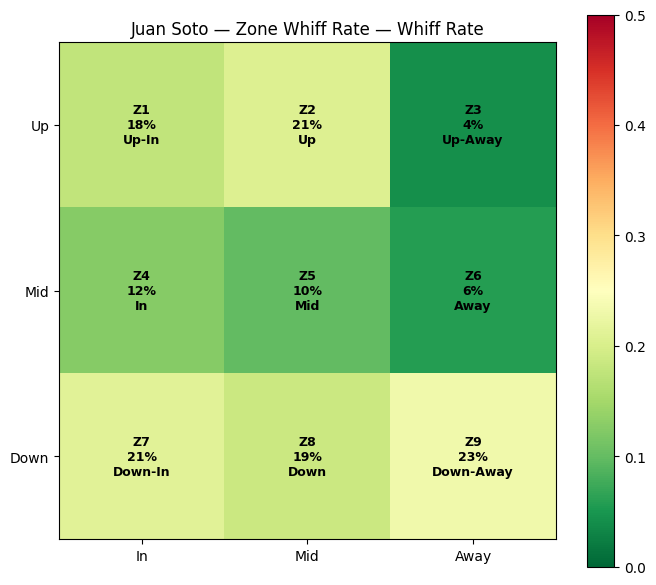

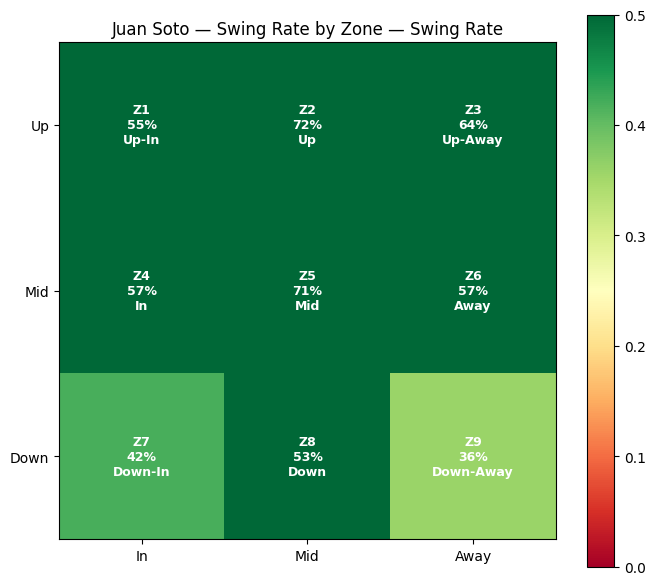

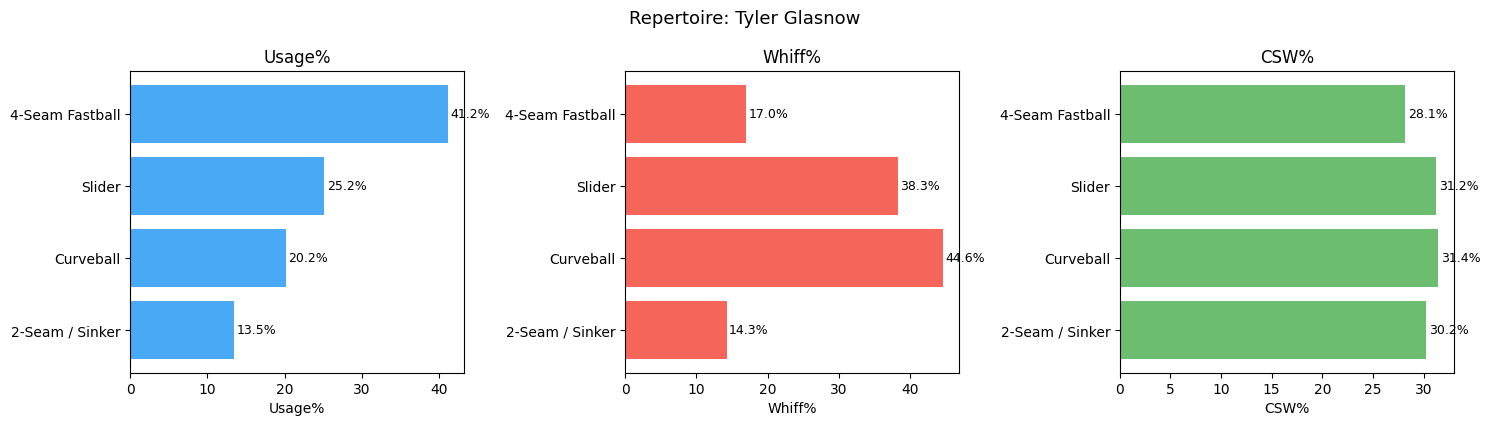

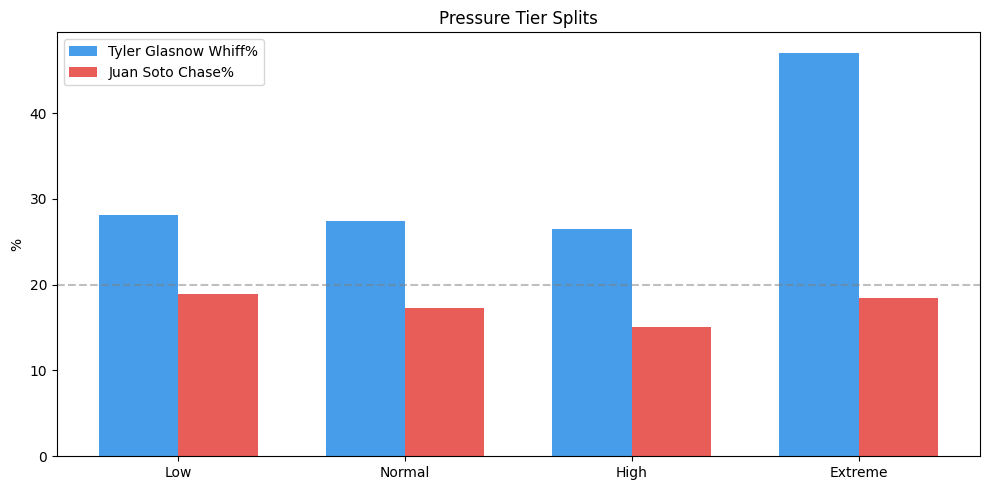

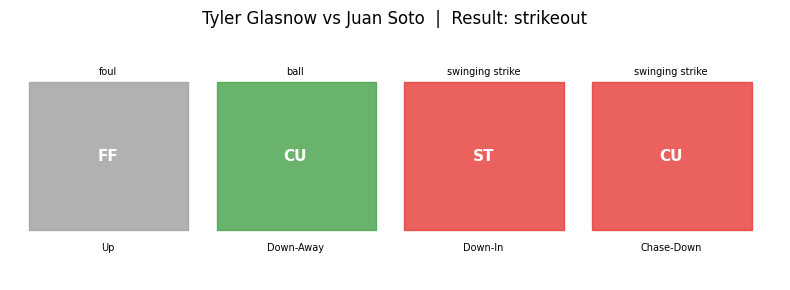

In [48]:
# VISUALIZE THE MATCHUP
plot_zone_heatmap(ai.batter.zone_map,  title='Juan Soto — Zone Whiff Rate',  metric='whiff_rate')
plot_zone_heatmap(ai.batter.zone_map,  title='Juan Soto — Swing Rate by Zone', metric='swing_rate')
plot_repertoire(ai.pitcher)
plot_pressure(ai.pitcher, ai.batter)
plot_ab_timeline(ai.ab)

In [49]:
# INTERACTIVE MODE — type your own pitch results
# Start a new at-bat scenario first
ai.start_at_bat(inning=9, outs=2, on_base='_23',
                home_score=0, away_score=1, game_type='W')
ai.run_interactive()


  AT-BAT: Tyler Glasnow vs Juan Soto
  Inning 9 | Outs: 2 | Runners: _23
  0–1 | World Series
  Leverage: 5.00 [EXTREME PRESSURE]

  INTERACTIVE MODE: Tyler Glasnow vs Juan Soto
  Format: PITCH ZONE RESULT [EVENTS] [VELOCITY]
  e.g.:   FF 2 foul 98.4
  Type 'quit' to exit.

  Count: 0-0  |  Leverage: 5.00 [Extreme]  |  Momentum: — Neutral

  PITCHCOM — 1st PITCH:

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  #1  [CURVEBALL] → [CHASE-IN]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Pitch:     Curveball
  Location:  Off plate inside (chase)
  Count:     0-0  |  Pressure: 🚨 EXTREME
  Score:     48.5  (CSW 31%  Whiff 45%)
  ML Conf: 14%

  Why:
    • Zone 13 is batter's weak spot (50% whiff)
    • HIGH LEVERAGE (5.0): prioritise swing-miss pitch
    • Extreme pressure: reduce chase (no walks)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  #2  [SLIDER] → [DOWN-AWAY]
━━━

In [50]:
# ADD ANY PLAYER — look up MLB ID then pass explicitly
# lookup_player('Paul Skenes')
# lookup_player('Yoshinobu Yamamoto')
# lookup_player('Gunnar Henderson')

# Then:
# ai.load_matchup('Paul Skenes', 'Aaron Judge', pitcher_id=694973, batter_id=592450)

print('Use lookup_player("First Last") to find MLB IDs.')
print('Then: ai.load_matchup(name1, name2, pitcher_id=X, batter_id=Y)')

Use lookup_player("First Last") to find MLB IDs.
Then: ai.load_matchup(name1, name2, pitcher_id=X, batter_id=Y)
